<a href="https://colab.research.google.com/github/andresZam12/CAlsof/blob/main/tallerMin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1: Predicción del precio del dólar

Primero, importaremos las librerías necesarias y cargaremos el dataset `dolar_data.csv`.

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df_dolar = pd.read_csv('/content/dolar_data.csv')

# Mostrar las primeras filas del dataset y su información
print('Primeras 5 filas del dataset:')
display(df_dolar.head())

print('\nInformación del dataset:')
df_dolar.info()

Primeras 5 filas del dataset:


,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Dia           500 non-null    int64  
 1   Inflacion     500 non-null    float64
 2   Tasa_interes  500 non-null    float64
 3   Precio_Dolar  500 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.8 KB


### 1. Ajustar un modelo de regresión lineal múltiple para predecir Precio_Dolar

In [7]:
# Definir las variables independientes (X) y la variable dependiente (y)
X_dolar = df_dolar[['Dia', 'Inflacion', 'Tasa_interes']]
y_dolar = df_dolar['Precio_Dolar']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_dolar, X_test_dolar, y_train_dolar, y_test_dolar = train_test_split(X_dolar, y_dolar, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model_dolar = LinearRegression()
model_dolar.fit(X_train_dolar, y_train_dolar)

print("Modelo de Regresión Lineal para el Precio del Dólar entrenado exitosamente.")

Modelo de Regresión Lineal para el Precio del Dólar entrenado exitosamente.


### 2. Interpretar los coeficientes del modelo

Los coeficientes nos indican cómo cambia la variable dependiente (`Precio_Dolar`) por cada unidad de cambio en la variable independiente correspondiente, manteniendo las otras variables constantes.

In [8]:
print('Coeficientes del modelo:')
for feature, coef in zip(X_dolar.columns, model_dolar.coef_):
    print(f'{feature}: {coef:.4f}')
print(f'Intercepción (bias): {model_dolar.intercept_:.4f}')

Coeficientes del modelo:
Dia: 4.9843
Inflacion: -870.7317
Tasa_interes: -1.3774
Intercepción (bias): 3985.7833


### 3. Evaluar el desempeño del modelo utilizando error medio cuadrático (MSE) y R²

- **Error Cuadrático Medio (MSE):** Mide el promedio de los errores al cuadrado. Un valor más bajo indica un mejor ajuste del modelo.
- **R² (Coeficiente de Determinación):** Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor más cercano a 1 indica que el modelo explica una gran parte de la variabilidad.

In [9]:
# Realizar predicciones en el conjunto de prueba
y_pred_dolar = model_dolar.predict(X_test_dolar)

# Calcular MSE y R²
mse_dolar = mean_squared_error(y_test_dolar, y_pred_dolar)
r2_dolar = r2_score(y_test_dolar, y_pred_dolar)

print(f'Error Cuadrático Medio (MSE): {mse_dolar:.4f}')
print(f'R²: {r2_dolar:.4f}')

Error Cuadrático Medio (MSE): 2376.9709
R²: 0.9963


### 4. Graficar la relación de cada variable independiente con Precio_Dolar

Visualizaremos cómo cada variable independiente se relaciona con el `Precio_Dolar`.

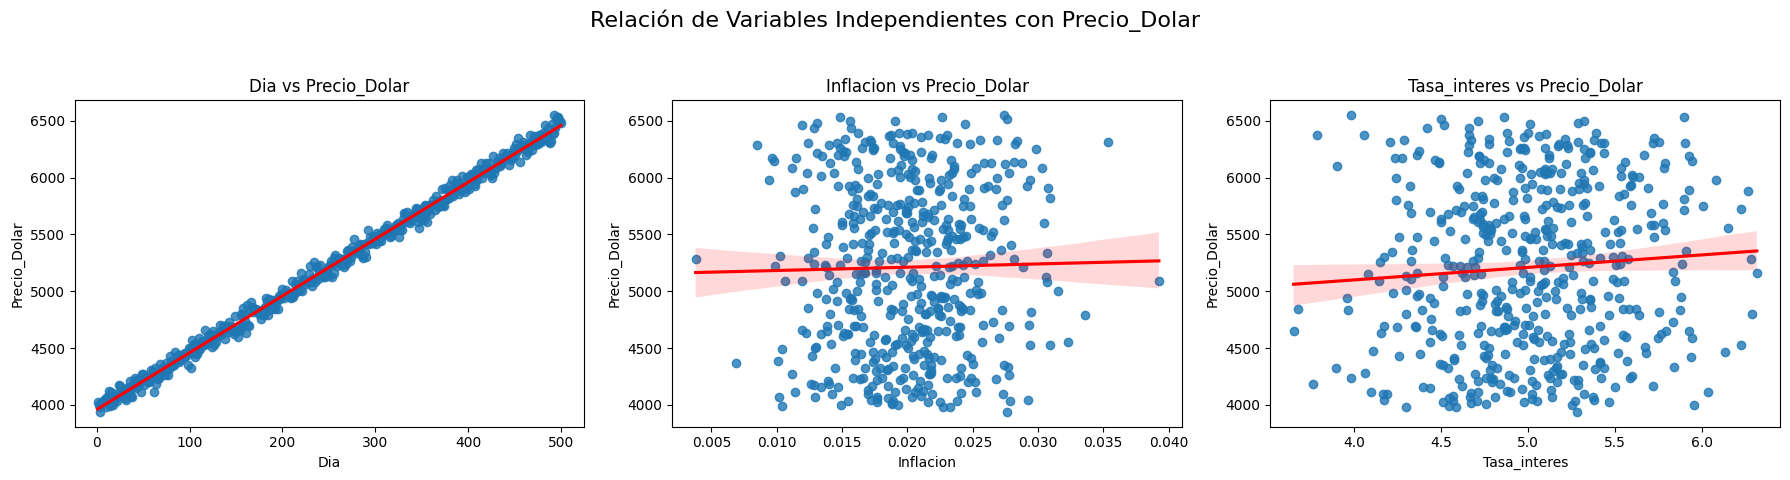

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Variables Independientes con Precio_Dolar', fontsize=16)

sns.regplot(x='Dia', y='Precio_Dolar', data=df_dolar, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Dia vs Precio_Dolar')

sns.regplot(x='Inflacion', y='Precio_Dolar', data=df_dolar, ax=axes[1], line_kws={'color': 'red'})
axes[1].set_title('Inflacion vs Precio_Dolar')

sns.regplot(x='Tasa_interes', y='Precio_Dolar', data=df_dolar, ax=axes[2], line_kws={'color': 'red'})
axes[2].set_title('Tasa_interes vs Precio_Dolar')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Ejercicio 2: Predicción de niveles de glucosa en sangre

Comenzaremos cargando el dataset `glucosa_data.csv` y preparando los datos para el modelo de regresión lineal.

In [11]:
# Cargar el dataset de glucosa
df_glucosa = pd.read_csv('/content/glucosa_data.csv')

# Mostrar las primeras filas del dataset y su información
print('Primeras 5 filas del dataset de glucosa:')
display(df_glucosa.head())

print('\nInformación del dataset de glucosa:')
df_glucosa.info()

Primeras 5 filas del dataset de glucosa:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730



Información del dataset de glucosa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Edad              2000 non-null   int64  
 1   IMC               2000 non-null   float64
 2   Actividad_Fisica  2000 non-null   int64  
 3   Nivel_Glucosa     2000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 62.6 KB


### 1. Ajustar un modelo de regresión lineal múltiple para predecir Nivel_Glucosa

In [12]:
# Definir las variables independientes (X) y la variable dependiente (y)
X_glucosa = df_glucosa[['Edad', 'IMC', 'Actividad_Fisica']]
y_glucosa = df_glucosa['Nivel_Glucosa']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_glucosa, X_test_glucosa, y_train_glucosa, y_test_glucosa = train_test_split(X_glucosa, y_glucosa, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model_glucosa = LinearRegression()
model_glucosa.fit(X_train_glucosa, y_train_glucosa)

print("Modelo de Regresión Lineal para el Nivel de Glucosa entrenado exitosamente.")

Modelo de Regresión Lineal para el Nivel de Glucosa entrenado exitosamente.


### 2. Interpretar los coeficientes del modelo y evaluar la importancia de cada variable

In [13]:
print('Coeficientes del modelo de glucosa:')
for feature, coef in zip(X_glucosa.columns, model_glucosa.coef_):
    print(f'{feature}: {coef:.4f}')
print(f'Intercepción (bias): {model_glucosa.intercept_:.4f}')

Coeficientes del modelo de glucosa:
Edad: 1.2266
IMC: 0.9334
Actividad_Fisica: -2.0853
Intercepción (bias): 65.8609


### 3. Evaluar el desempeño del modelo con MSE y R²

In [14]:
# Realizar predicciones en el conjunto de prueba
y_pred_glucosa = model_glucosa.predict(X_test_glucosa)

# Calcular MSE y R²
mse_glucosa = mean_squared_error(y_test_glucosa, y_pred_glucosa)
r2_glucosa = r2_score(y_test_glucosa, y_pred_glucosa)

print(f'Error Cuadrático Medio (MSE) para glucosa: {mse_glucosa:.4f}')
print(f'R² para glucosa: {r2_glucosa:.4f}')

Error Cuadrático Medio (MSE) para glucosa: 233.6930
R² para glucosa: 0.6814


### 4. Graficar la relación de cada variable independiente con Nivel_Glucosa

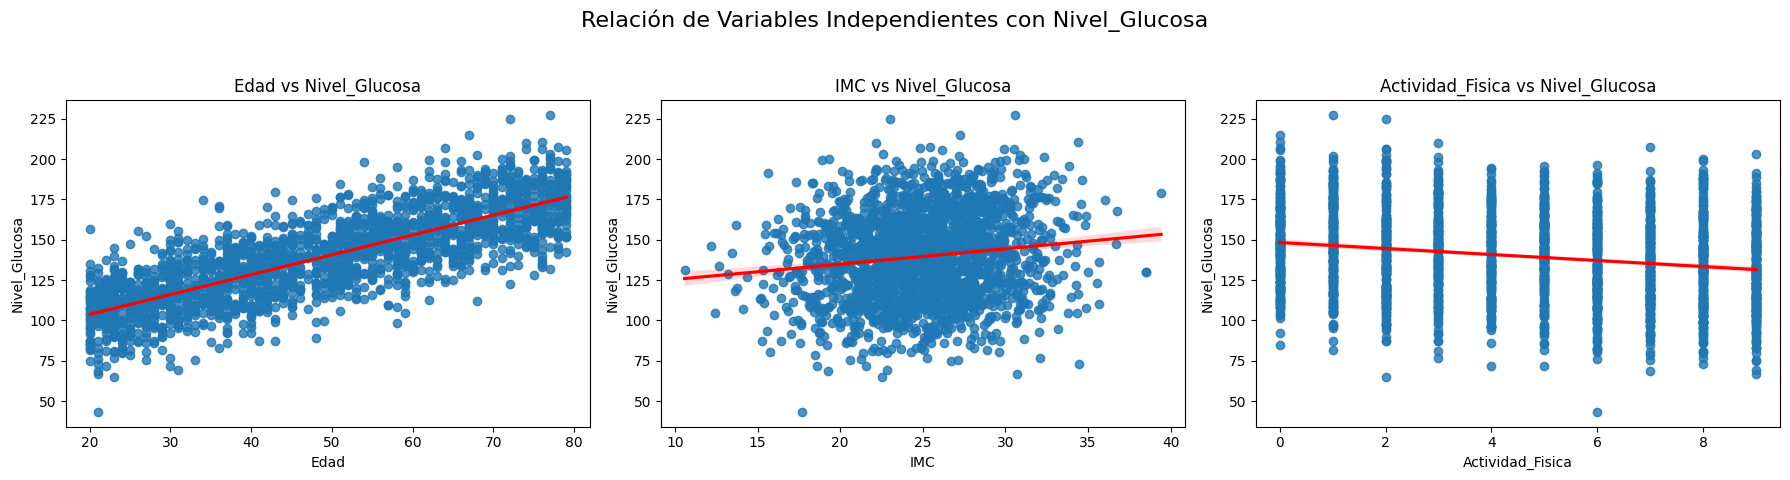

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Variables Independientes con Nivel_Glucosa', fontsize=16)

sns.regplot(x='Edad', y='Nivel_Glucosa', data=df_glucosa, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Edad vs Nivel_Glucosa')

sns.regplot(x='IMC', y='Nivel_Glucosa', data=df_glucosa, ax=axes[1], line_kws={'color': 'red'})
axes[1].set_title('IMC vs Nivel_Glucosa')

sns.regplot(x='Actividad_Fisica', y='Nivel_Glucosa', data=df_glucosa, ax=axes[2], line_kws={'color': 'red'})
axes[2].set_title('Actividad_Fisica vs Nivel_Glucosa')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Analizar qué variable tiene mayor impacto en el nivel de glucosa

Para determinar qué variable tiene mayor impacto, podemos observar la magnitud absoluta de los coeficientes estandarizados (o los coeficientes originales si las escalas de las variables son comparables, lo cual no siempre es el caso). Sin embargo, una forma más robusta es comparar los valores absolutos de los coeficientes del modelo directamente.

In [16]:
coeficientes_absolutos_glucosa = pd.Series(model_glucosa.coef_, index=X_glucosa.columns).abs()
variable_mayor_impacto_glucosa = coeficientes_absolutos_glucosa.idxmax()

print(f"La variable con mayor impacto en el Nivel_Glucosa es: {variable_mayor_impacto_glucosa} (con un coeficiente absoluto de {coeficientes_absolutos_glucosa.max():.4f})")

La variable con mayor impacto en el Nivel_Glucosa es: Actividad_Fisica (con un coeficiente absoluto de 2.0853)


### Exportación del modelo de regresión de glucosa

Vamos a guardar el modelo entrenado (`model_glucosa`) utilizando la librería `joblib`. Esto nos permitirá cargarlo y usarlo para predicciones futuras sin tener que reentrenarlo.

In [17]:
import joblib

# Guardar el modelo de regresión de glucosa
joblib.dump(model_glucosa, 'glucosa_model.joblib')
print("Modelo de glucosa guardado como 'glucosa_model.joblib'")

Modelo de glucosa guardado como 'glucosa_model.joblib'


In [18]:
import joblib

# Guardar el modelo de regresión de glucosa
joblib.dump(model_glucosa, 'glucosa_model.joblib')
print("Modelo de glucosa guardado como 'glucosa_model.joblib'")

Modelo de glucosa guardado como 'glucosa_model.joblib'


In [19]:
import joblib

# Guardar el modelo de regresión de glucosa
joblib.dump(model_glucosa, 'glucosa_model.joblib')
print("Modelo de glucosa guardado como 'glucosa_model.joblib'")

Modelo de glucosa guardado como 'glucosa_model.joblib'


## Ejercicio 3: Predicción del consumo de energía eléctrica

Ahora, trabajaremos con el dataset `energia_data.csv` para predecir el consumo de energía eléctrica.

In [20]:
# Cargar el dataset de energía
df_energia = pd.read_csv('/content/energia_data.csv')

# Mostrar las primeras filas del dataset y su información
print('Primeras 5 filas del dataset de energía:')
display(df_energia.head())

print('\nInformación del dataset de energía:')
df_energia.info()

Primeras 5 filas del dataset de energía:


,Temperatura,Hora,Dia_Semana,Consumo_Energia
0,28.891805,1,1,401.990602
1,22.244071,2,2,334.846911
2,20.909006,3,3,326.926080
3,24.983128,4,4,383.016951
4,24.149077,5,5,388.748151



Información del dataset de energía:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      10000 non-null  float64
 1   Hora             10000 non-null  int64  
 2   Dia_Semana       10000 non-null  int64  
 3   Consumo_Energia  10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


### 1. Ajustar un modelo de regresión lineal múltiple para predecir Consumo_Energia

In [21]:
# Definir las variables independientes (X) y la variable dependiente (y)
X_energia = df_energia[['Temperatura', 'Hora', 'Dia_Semana']]
y_energia = df_energia['Consumo_Energia']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_energia, X_test_energia, y_train_energia, y_test_energia = train_test_split(X_energia, y_energia, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model_energia = LinearRegression()
model_energia.fit(X_train_energia, y_train_energia)

print("Modelo de Regresión Lineal para el Consumo de Energía entrenado exitosamente.")

Modelo de Regresión Lineal para el Consumo de Energía entrenado exitosamente.


### 2. Determinar qué variable tiene mayor impacto en el consumo de energía

In [22]:
print('Coeficientes del modelo de energía:')
for feature, coef in zip(X_energia.columns, model_energia.coef_):
    print(f'{feature}: {coef:.4f}')
print(f'Intercepción (bias): {model_energia.intercept_:.4f}')

coeficientes_absolutos_energia = pd.Series(model_energia.coef_, index=X_energia.columns).abs()
variable_mayor_impacto_energia = coeficientes_absolutos_energia.idxmax()

print(f"\nLa variable con mayor impacto en el Consumo_Energia es: {variable_mayor_impacto_energia} (con un coeficiente absoluto de {coeficientes_absolutos_energia.max():.4f})")

Coeficientes del modelo de energía:
Temperatura: 9.9529
Hora: 5.0198
Dia_Semana: -3.0312
Intercepción (bias): 101.2882

La variable con mayor impacto en el Consumo_Energia es: Temperatura (con un coeficiente absoluto de 9.9529)


### 3. Evaluar el desempeño del modelo usando RMSE y R²

In [23]:
# Realizar predicciones en el conjunto de prueba
y_pred_energia = model_energia.predict(X_test_energia)

# Calcular MSE (y luego RMSE) y R²
mse_energia = mean_squared_error(y_test_energia, y_pred_energia)
rmse_energia = np.sqrt(mse_energia)
r2_energia = r2_score(y_test_energia, y_pred_energia)

print(f'Error Cuadrático Medio (MSE) para energía: {mse_energia:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE) para energía: {rmse_energia:.4f}')
print(f'R² para energía: {r2_energia:.4f}')

Error Cuadrático Medio (MSE) para energía: 429.5187
Raíz del Error Cuadrático Medio (RMSE) para energía: 20.7248
R² para energía: 0.8968


### 4. Visualizar las relaciones más importantes mediante gráficas de dispersión o correlación

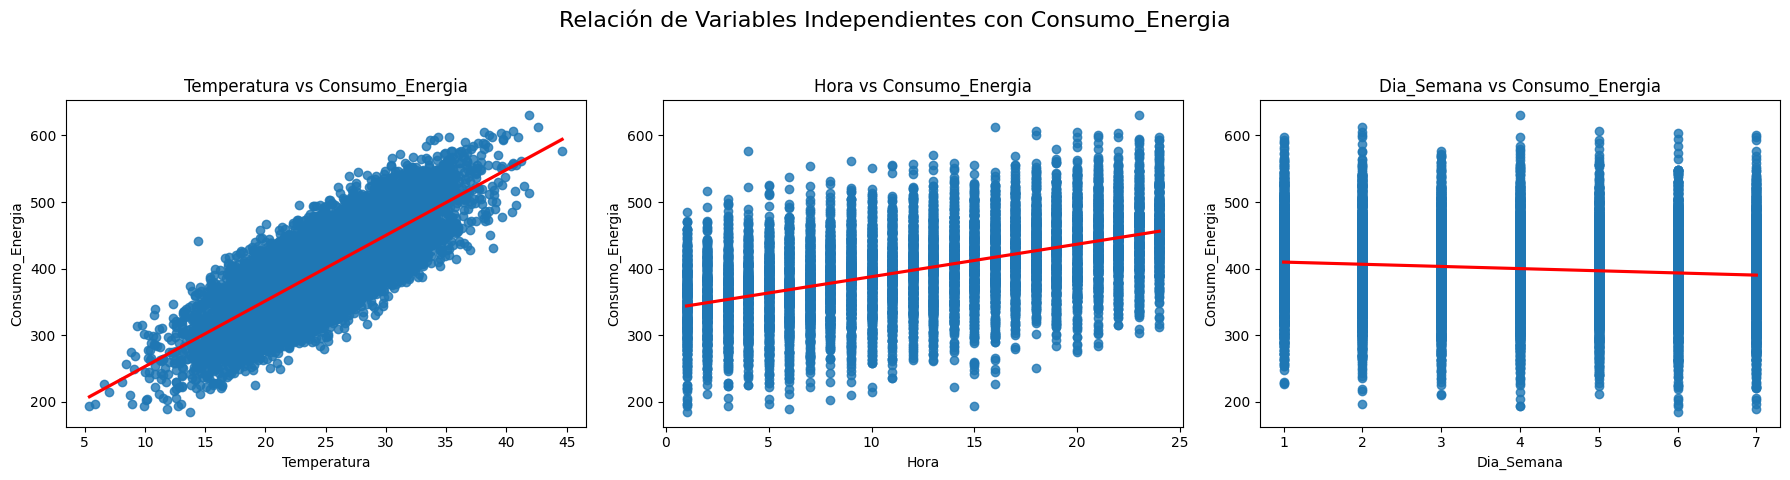

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Variables Independientes con Consumo_Energia', fontsize=16)

sns.regplot(x='Temperatura', y='Consumo_Energia', data=df_energia, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Temperatura vs Consumo_Energia')

sns.regplot(x='Hora', y='Consumo_Energia', data=df_energia, ax=axes[1], line_kws={'color': 'red'})
axes[1].set_title('Hora vs Consumo_Energia')

sns.regplot(x='Dia_Semana', y='Consumo_Energia', data=df_energia, ax=axes[2], line_kws={'color': 'red'})
axes[2].set_title('Dia_Semana vs Consumo_Energia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Entregables Complementarias

### 1. Exportación de los modelos

Exportaremos los tres modelos entrenados (`model_dolar`, `model_glucosa` y `model_energia`) usando `joblib` para su uso posterior.

In [25]:
# Guardar el modelo de regresión de dólar
joblib.dump(model_dolar, 'dolar_model.joblib')
print("Modelo de dólar guardado como 'dolar_model.joblib'")

# Guardar el modelo de regresión de energía
joblib.dump(model_energia, 'energia_model.joblib')
print("Modelo de energía guardado como 'energia_model.joblib'")

Modelo de dólar guardado como 'dolar_model.joblib'
Modelo de energía guardado como 'energia_model.joblib'


### 2. Desarrollo de interfaz web básica

Para el desarrollo de una interfaz web básica que permita a los usuarios ingresar valores y obtener predicciones para cada uno de los tres ejercicios (Dólar, Glucosa, Energía), la librería `Streamlit` es una excelente opción por su facilidad de uso y rapidez para prototipar aplicaciones de datos en Python.

A continuación, se presenta un esquema general de cómo podrías estructurar tu aplicación Streamlit. Tendrías que guardarlo como un archivo `.py` (por ejemplo, `app.py`) y ejecutarlo desde tu terminal con `streamlit run app.py`.

**Estructura del archivo `app.py` (ejemplo conceptual):**

```python
import streamlit as st
import joblib
import pandas as pd

# --- Cargar los modelos entrenados ---
# Asegúrate de que estos archivos .joblib estén en el mismo directorio que tu app.py
try:
    model_dolar = joblib.load('dolar_model.joblib')
    model_glucosa = joblib.load('glucosa_model.joblib')
    model_energia = joblib.load('energia_model.joblib')
except FileNotFoundError:
    st.error("Error: No se pudieron cargar los modelos. Asegúrate de que los archivos .joblib estén en el directorio correcto.")
    st.stop() # Detiene la ejecución de la app si los modelos no se cargan

# --- Configuración de la aplicación ---
st.set_page_config(page_title="Predicción de Variables", layout="centered")
st.title('Aplicación de Predicción')

# --- Selector de Ejercicio ---
ejercicio_seleccionado = st.sidebar.selectbox(
    'Selecciona el Ejercicio',
    ('Predicción del Precio del Dólar', 'Predicción de Nivel de Glucosa', 'Predicción de Consumo de Energía')
)

st.header(ejercicio_seleccionado)

# --- Lógica para cada ejercicio ---
if ejercicio_seleccionado == 'Predicción del Precio del Dólar':
    st.subheader('Ingresa los valores para predecir el Precio del Dólar')
    dia = st.number_input('Día', min_value=1, max_value=1000, value=501)
    inflacion = st.number_input('Inflación (ej. 0.02 para 2%)', min_value=0.0, max_value=1.0, value=0.02, format="%.5f")
    tasa_interes = st.number_input('Tasa de Interés', min_value=0.0, max_value=10.0, value=5.0, format="%.3f")

    if st.button('Predecir Precio del Dólar'):
        input_data = pd.DataFrame([[dia, inflacion, tasa_interes]], columns=['Dia', 'Inflacion', 'Tasa_interes'])
        prediccion = model_dolar.predict(input_data)[0]
        st.success(f'El Precio del Dólar predicho es: {prediccion:.2f}')

elif ejercicio_seleccionado == 'Predicción de Nivel de Glucosa':
    st.subheader('Ingresa los valores para predecir el Nivel de Glucosa')
    edad = st.number_input('Edad', min_value=1, max_value=120, value=30)
    imc = st.number_input('IMC', min_value=10.0, max_value=50.0, value=25.0, format="%.2f")
    actividad_fisica = st.number_input('Actividad Física (horas semanales)', min_value=0.0, max_value=50.0, value=5.0, format="%.2f")

    if st.button('Predecir Nivel de Glucosa'):
        input_data = pd.DataFrame([[edad, imc, actividad_fisica]], columns=['Edad', 'IMC', 'Actividad_Fisica'])
        prediccion = model_glucosa.predict(input_data)[0]
        st.success(f'El Nivel de Glucosa predicho es: {prediccion:.2f} mg/dL')

elif ejercicio_seleccionado == 'Predicción de Consumo de Energía':
    st.subheader('Ingresa los valores para predecir el Consumo de Energía')
    temperatura = st.number_input('Temperatura (°C)', min_value=-20.0, max_value=50.0, value=20.0, format="%.2f")
    hora = st.number_input('Hora del Día (1-24)', min_value=1, max_value=24, value=12)
    dia_semana = st.number_input('Día de la Semana (1=Lunes, 7=Domingo)', min_value=1, max_value=7, value=3)

    if st.button('Predecir Consumo de Energía'):
        input_data = pd.DataFrame([[temperatura, hora, dia_semana]], columns=['Temperatura', 'Hora', 'Dia_Semana'])
        prediccion = model_energia.predict(input_data)[0]
        st.success(f'El Consumo de Energía predicho es: {prediccion:.2f} kWh')
```

**Pasos para implementar la interfaz web:**

1.  **Instala Streamlit:** Si no lo tienes, usa `pip install streamlit`. Luego, para ejecutarlo en Colab, deberás instalar `pyngrok` (`pip install pyngrok`) y usarlo para exponer el puerto. Aquí un ejemplo:

    ```python
    # En una celda de Colab:
    # !pip install streamlit pyngrok
    # from pyngrok import ngrok
    # public_url = ngrok.connect(port='8501') # El puerto por defecto de Streamlit es 8501
    # print(public_url)
    # !streamlit run app.py
    ```

2.  **Crea el archivo `app.py`:** Guarda el código de ejemplo anterior en un archivo llamado `app.py` en tu entorno de trabajo (por ejemplo, en la carpeta `/content/`).
3.  **Asegúrate de tener los modelos:** Los archivos `dolar_model.joblib`, `glucosa_model.joblib` y `energia_model.joblib` deben estar en el mismo directorio que `app.py`.
4.  **Ejecuta la aplicación:** Desde tu terminal (o una celda de Colab como se indicó arriba), ejecuta `streamlit run app.py`. Esto abrirá la interfaz web en tu navegador.

## Regenerando Ejercicio 2: Predicción de niveles de glucosa en sangre (Para asegurar la definición del modelo)

Vamos a ejecutar nuevamente los pasos para el 'Ejercicio 2' para garantizar que `model_glucosa` esté definido y luego podamos guardarlo.

In [26]:
# Cargar el dataset de glucosa
df_glucosa = pd.read_csv('/content/glucosa_data.csv')

print('Primeras 5 filas del dataset de glucosa:')
display(df_glucosa.head())

print('\nInformación del dataset de glucosa:')
df_glucosa.info()

Primeras 5 filas del dataset de glucosa:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730



Información del dataset de glucosa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Edad              2000 non-null   int64  
 1   IMC               2000 non-null   float64
 2   Actividad_Fisica  2000 non-null   int64  
 3   Nivel_Glucosa     2000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 62.6 KB


### 1. Ajustar un modelo de regresión lineal múltiple para predecir Nivel_Glucosa

In [27]:
# Definir las variables independientes (X) y la variable dependiente (y)
X_glucosa = df_glucosa[['Edad', 'IMC', 'Actividad_Fisica']]
y_glucosa = df_glucosa['Nivel_Glucosa']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_glucosa, X_test_glucosa, y_train_glucosa, y_test_glucosa = train_test_split(X_glucosa, y_glucosa, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model_glucosa = LinearRegression()
model_glucosa.fit(X_train_glucosa, y_train_glucosa)

print("Modelo de Regresión Lineal para el Nivel de Glucosa entrenado exitosamente.")

Modelo de Regresión Lineal para el Nivel de Glucosa entrenado exitosamente.


### 2. Interpretar los coeficientes del modelo y evaluar la importancia de cada variable

In [28]:
print('Coeficientes del modelo de glucosa:')
for feature, coef in zip(X_glucosa.columns, model_glucosa.coef_):
    print(f'{feature}: {coef:.4f}')
print(f'Intercepción (bias): {model_glucosa.intercept_:.4f}')

Coeficientes del modelo de glucosa:
Edad: 1.2266
IMC: 0.9334
Actividad_Fisica: -2.0853
Intercepción (bias): 65.8609


### 3. Evaluar el desempeño del modelo con MSE y R²

In [29]:
# Realizar predicciones en el conjunto de prueba
y_pred_glucosa = model_glucosa.predict(X_test_glucosa)

# Calcular MSE y R²
mse_glucosa = mean_squared_error(y_test_glucosa, y_pred_glucosa)
r2_glucosa = r2_score(y_test_glucosa, y_pred_glucosa)

print(f'Error Cuadrático Medio (MSE) para glucosa: {mse_glucosa:.4f}')
print(f'R² para glucosa: {r2_glucosa:.4f}')

Error Cuadrático Medio (MSE) para glucosa: 233.6930
R² para glucosa: 0.6814


### 4. Graficar la relación de cada variable independiente con Nivel_Glucosa

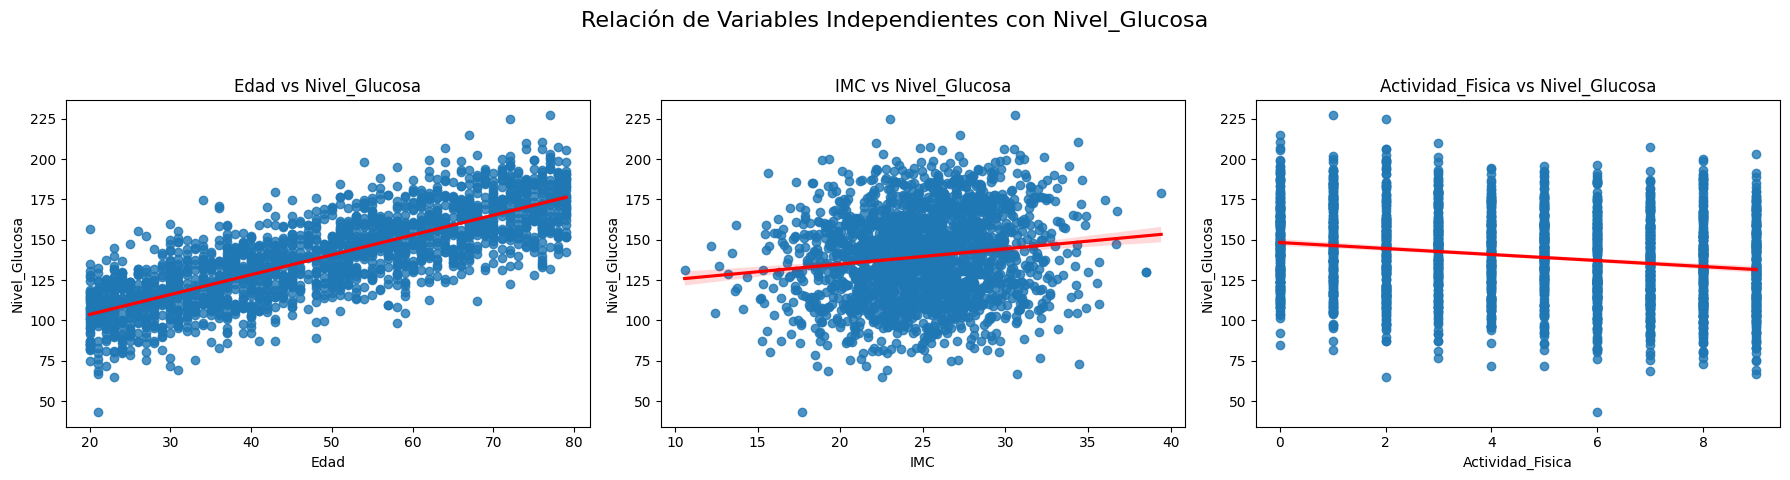

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Variables Independientes con Nivel_Glucosa', fontsize=16)

sns.regplot(x='Edad', y='Nivel_Glucosa', data=df_glucosa, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Edad vs Nivel_Glucosa')

sns.regplot(x='IMC', y='Nivel_Glucosa', data=df_glucosa, ax=axes[1], line_kws={'color': 'red'})
axes[1].set_title('IMC vs Nivel_Glucosa')

sns.regplot(x='Actividad_Fisica', y='Nivel_Glucosa', data=df_glucosa, ax=axes[2], line_kws={'color': 'red'})
axes[2].set_title('Actividad_Fisica vs Nivel_Glucosa')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Analizar qué variable tiene mayor impacto en el nivel de glucosa

In [31]:
coeficientes_absolutos_glucosa = pd.Series(model_glucosa.coef_, index=X_glucosa.columns).abs()
variable_mayor_impacto_glucosa = coeficientes_absolutos_glucosa.idxmax()

print(f"La variable con mayor impacto en el Nivel_Glucosa es: {variable_mayor_impacto_glucosa} (con un coeficiente absoluto de {coeficientes_absolutos_glucosa.max():.4f})")

La variable con mayor impacto en el Nivel_Glucosa es: Actividad_Fisica (con un coeficiente absoluto de 2.0853)


### Exportación del modelo de regresión de glucosa

In [32]:
import joblib

# Guardar el modelo de regresión de glucosa
joblib.dump(model_glucosa, 'glucosa_model.joblib')
print("Modelo de glucosa guardado como 'glucosa_model.joblib'")

Modelo de glucosa guardado como 'glucosa_model.joblib'


### Configuración y Ejecución de la Interfaz Web con Streamlit en Colab

Vamos a instalar las librerías necesarias, crear el archivo `app.py` con el código de Streamlit y luego ejecutarlo usando `ngrok` para obtener una URL pública.

In [33]:
# 1. Instalar Streamlit y pyngrok
!pip install -q streamlit pyngrok

# 2. Importar ngrok para exponer el puerto de Streamlit
from pyngrok import ngrok
import os

print("Librerías instaladas.")

Librerías instaladas.


In [34]:
# 3. Crear el archivo app.py con el código de Streamlit

app_code = '''
import streamlit as st
import joblib
import pandas as pd

# --- Cargar los modelos entrenados ---
try:
    model_dolar = joblib.load('dolar_model.joblib')
    model_glucosa = joblib.load('glucosa_model.joblib')
    model_energia = joblib.load('energia_model.joblib')
except FileNotFoundError:
    st.error("Error: No se pudieron cargar los modelos. Asegúrate de que los archivos .joblib estén en el directorio correcto.")
    st.stop() # Detiene la ejecución de la app si los modelos no se cargan

# --- Configuración de la aplicación ---
st.set_page_config(page_title="Predicción de Variables", layout="centered")
st.title('Aplicación de Predicción de Modelos de Regresión')

# --- Selector de Ejercicio ---
ejercicio_seleccionado = st.sidebar.selectbox(
    'Selecciona el Ejercicio',
    ('Predicción del Precio del Dólar', 'Predicción de Nivel de Glucosa', 'Predicción de Consumo de Energía')
)

st.header(ejercicio_seleccionado)

# --- Lógica para cada ejercicio ---
if ejercicio_seleccionado == 'Predicción del Precio del Dólar':
    st.subheader('Ingresa los valores para predecir el Precio del Dólar')
    dia = st.number_input('Día', min_value=1, max_value=1000, value=501)
    inflacion = st.number_input('Inflación (ej. 0.02 para 2%)', min_value=0.0, max_value=1.0, value=0.02, format="%.5f")
    tasa_interes = st.number_input('Tasa de Interés', min_value=0.0, max_value=10.0, value=5.0, format="%.3f")

    if st.button('Predecir Precio del Dólar'):
        input_data = pd.DataFrame([[dia, inflacion, tasa_interes]], columns=['Dia', 'Inflacion', 'Tasa_interes'])
        prediccion = model_dolar.predict(input_data)[0]
        st.success(f'El Precio del Dólar predicho es: {prediccion:.2f}')

elif ejercicio_seleccionado == 'Predicción de Nivel de Glucosa':
    st.subheader('Ingresa los valores para predecir el Nivel de Glucosa')
    edad = st.number_input('Edad', min_value=1, max_value=120, value=30)
    imc = st.number_input('IMC', min_value=10.0, max_value=50.0, value=25.0, format="%.2f")
    actividad_fisica = st.number_input('Actividad Física (horas semanales)', min_value=0.0, max_value=50.0, value=5.0, format="%.2f")

    if st.button('Predecir Nivel de Glucosa'):
        input_data = pd.DataFrame([[edad, imc, actividad_fisica]], columns=['Edad', 'IMC', 'Actividad_Fisica'])
        prediccion = model_glucosa.predict(input_data)[0]
        st.success(f'El Nivel de Glucosa predicho es: {prediccion:.2f} mg/dL')

elif ejercicio_seleccionado == 'Predicción de Consumo de Energía':
    st.subheader('Ingresa los valores para predecir el Consumo de Energía')
    temperatura = st.number_input('Temperatura (°C)', min_value=-20.0, max_value=50.0, value=20.0, format="%.2f")
    hora = st.number_input('Hora del Día (0-23)', min_value=0, max_value=23, value=12)
    dia_semana = st.number_input('Día de la Semana (1=Lunes, 7=Domingo)', min_value=1, max_value=7, value=3)

    if st.button('Predecir Consumo de Energía'):
        input_data = pd.DataFrame([[temperatura, hora, dia_semana]], columns=['Temperatura', 'Hora', 'Dia_Semana'])
        prediccion = model_energia.predict(input_data)[0]
        st.success(f'El Consumo de Energía predicho es: {prediccion:.2f} kWh')
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("Archivo 'app.py' creado.")

Archivo 'app.py' creado.


In [35]:
# 4. Obtener un token de autenticación de ngrok

from getpass import getpass
import os


ngrok.set_auth_token("3K9OdDPzFIUbtJKwzJNntE2zGEk_43jVK1Ks5BvGbRVtWw3SG")

# Iniciar ngrok para exponer el puerto 8501 (puerto por defecto de Streamlit)
public_url = ngrok.connect(addr='8501', proto='http')
print(f"\n¡Tu aplicación Streamlit está disponible en: {public_url}!")


!streamlit run app.py --server.port 8501


¡Tu aplicación Streamlit está disponible en: NgrokTunnel: "https://viscosity-drastic-wrangle.ngrok-free.dev" -> "http://localhost:8501"!


2026-10-02 20:53:47.905 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.63.207.237:8501

  Stopping...
  Stopping...
